 # Deep Learning Competition 2

 ## Team 13
113062644  
113501525  
112078502  



Your report(.ipynb file) should have:
- Your code
- What kind of models you have tried and how did they work.
- Anything you've done and want to tell us.
- What problems occured and how did you solve them.

https://www.kaggle.com/competitions/2025-data-lab-cup-2-cnn-for-object-detection

# 1. import and check gpu

In [ ]:
import os
import tensorflow as tf
# data
import numpy as np
from collections import Counter # to check
# object detect model
from tensorflow import keras
from tensorflow.keras import layers

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        tf.config.experimental.set_visible_devices(gpus[0], 'GPU')
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), 'Physical GPUs,', len(logical_gpus), 'Logical GPUs')
    except RuntimeError as e:
        print(e)


1 Physical GPUs, 1 Logical GPUs


# 2. Hyperparemeter Setting

In [ ]:
# common params
IMAGE_SIZE = 448
NUM_CLASSES = 20
MAX_OBJECTS_PER_IMAGE = 20
PER_RECORD_LEN = 5

# dataset params
TRAINING_DATA_PATH = './dataset/pascal_voc_training_data.txt'
TRAINING_IMAGE_DIR = './dataset/VOCdevkit_train/VOC2007/JPEGImages/'
TESTING_DATA_PATH = './dataset/pascal_voc_testing_data.txt'
TESTING_IMAGE_DIR = './dataset/VOCdevkit_test/VOC2007/JPEGImages/'

AUG_TRAINING_DATA_PATH = './dataset/pascal_voc_training_data_balanced.txt'
AUG_TRAINING_IMAGE_DIR = './dataset/VOCdevkit_train/VOC2007/JPEGImages_balanced/'

# model
CELL_SIZE = 7
BOXES_PER_CELL = 2
OBJECT_SCALE = 1
NOOBJECT_SCALE = 0.5
CLASS_SCALE = 1
COORD_SCALE = 5

EPOCHS = 30
BATCH_SIZE = 8 # from 8
LEARNING_RATE = 1e-5

# 3. Data preprocess and Dataset Def

## 3.1 Data Augmentation


In [ ]:
# class name
class_name_list = ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
                   'bus', 'car', 'cat', 'chair', 'cow',
                   'diningtable', 'dog', 'horse', 'motorbike', 'person',
                   'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']

class PrintDataCheck:
    def __init__(self, data_path, class_name_list,
                 max_objects_per_image=20, per_record_len=5):
        self.data_path = data_path
        self.class_name_list = class_name_list
        self.num_classes = len(class_name_list)
        self.max_objects_per_image = max_objects_per_image
        self.per_record_len = per_record_len

        self.image_names = []
        self.image_to_bboxes = {}
        self.class_count = np.zeros(self.num_classes, int)
        self.imgs_obs = []   # list of [(class_id, count), ...] per image
        self.total_objects_per_image = []

    def load_data(self):
        """Load file and collect per-image and per-class stats."""
        with open(self.data_path, 'r') as fin:
            for line in fin:
                tokens = line.strip().split()
                if not tokens:
                    continue
                img_name = tokens[0]
                self.image_names.append(img_name)

                records = [float(x) for x in tokens[1:]]
                limit = self.max_objects_per_image * self.per_record_len
                if len(records) > limit:
                    records = records[:limit]

                arr = np.array(records).reshape((-1, self.per_record_len))
                self.image_to_bboxes[img_name] = arr

                labels = [int(r[4]) for r in arr]
                cnt = Counter(labels)
                self.imgs_obs.append(sorted(cnt.items(), key=lambda x: x[1], reverse=True))

                for cls, n in cnt.items():
                    self.class_count[cls] += n

                self.total_objects_per_image.append(len(labels))

    def _print_class_summary(self):
        print("\n=== Overall class counts ===")
        for r in range(5):  # print 5 rows
            for c in range(self.num_classes // 5):
                i = r + c * 5
                print(f"{i:2d}) {self.class_name_list[i]:11} {self.class_count[i]:4d}",
                      end=('\n' if c == 3 else '\t'))

    def _print_top_images(self):
        print("\n=== Top 5 images with most different classes ===")
        idx_by_class_variety = sorted(
            range(len(self.imgs_obs)),
            key=lambda i: len(self.imgs_obs[i]),
            reverse=True
        )[:5]
        for i in idx_by_class_variety:
            num_classes = len(self.imgs_obs[i])
            total_objs = sum(cnt for _, cnt in self.imgs_obs[i])
            print(f"{self.image_names[i]:15s} | classes={num_classes:2d} | "
                  f"total={total_objs:2d} | detail={self.imgs_obs[i]}")
        print("\n=== Top 5 images with most total objects ===")
        idx_by_total = sorted(
            range(len(self.imgs_obs)),
            key=lambda i: sum(cnt for _, cnt in self.imgs_obs[i]),
            reverse=True
        )[:5]
        for i in idx_by_total:
            num_classes = len(self.imgs_obs[i])
            total_objs = sum(cnt for _, cnt in self.imgs_obs[i])
            print(f"{self.image_names[i]:15s} | total={total_objs:2d} | "
                  f"classes={num_classes:2d} | detail={self.imgs_obs[i]}")
    def run(self):
        self.load_data()
        self._print_class_summary()
        self._print_top_images()


In [ ]:
print("Original data (capping at 20 obs per entries )")
check_origin = PrintDataCheck(TRAINING_DATA_PATH, class_name_list)
check_origin.run()

Original data (capping at 20 obs per entries )

=== Overall class counts ===
 0) aeroplane    331	 5) bus          271	10) diningtable  309	15) pottedplant  603
 1) bicycle      412	 6) car         1634	11) dog          536	16) sheep        353
 2) bird         577	 7) cat          389	12) horse        403	17) sofa         419
 3) boat         398	 8) chair       1423	13) motorbike    387	18) train        328
 4) bottle       612	 9) cow          356	14) person      5318	19) tvmonitor    366

=== Top 5 images with most different classes ===
003284.jpg      | classes= 7 | total= 7 | detail=[(3, 1), (15, 1), (8, 1), (10, 1), (14, 1), (17, 1), (11, 1)]
003024.jpg      | classes= 6 | total= 9 | detail=[(15, 3), (19, 2), (17, 1), (8, 1), (1, 1), (14, 1)]
005160.jpg      | classes= 6 | total=13 | detail=[(8, 6), (10, 2), (15, 2), (19, 1), (14, 1), (4, 1)]
005923.jpg      | classes= 6 | total=19 | detail=[(15, 6), (8, 5), (1, 3), (14, 3), (17, 1), (19, 1)]
006029.jpg      | classes= 6 | total

In [ ]:
print("After pre-processed augemented data (capping at 20 obs per entries )")
check_aug = PrintDataCheck(AUG_TRAINING_DATA_PATH, class_name_list)
check_aug.run()

After pre-processed augemented data (capping at 20 obs per entries )

=== Overall class counts ===
 0) aeroplane   2995	 5) bus         2994	10) diningtable 2993	15) pottedplant 2931
 1) bicycle     2993	 6) car         2983	11) dog         2990	16) sheep       2995
 2) bird        2898	 7) cat         2995	12) horse       2993	17) sofa        2997
 3) boat        2992	 8) chair       2964	13) motorbike   2990	18) train       2996
 4) bottle      2882	 9) cow         2993	14) person      2864	19) tvmonitor   2993

=== Top 5 images with most different classes ===
aug_m_000106_003284.jpg | classes= 9 | total=11 | detail=[(14, 2), (18, 2), (3, 1), (15, 1), (8, 1), (10, 1), (17, 1), (11, 1), (13, 1)]
aug_cp_000223_003034.jpg | classes= 9 | total=11 | detail=[(8, 2), (14, 2), (10, 1), (17, 1), (15, 1), (4, 1), (2, 1), (1, 1), (5, 1)]
aug_m_000374_003694.jpg | classes= 9 | total=14 | detail=[(14, 5), (12, 2), (19, 1), (17, 1), (15, 1), (8, 1), (13, 1), (5, 1), (6, 1)]
aug_cp_000470_003694.jp

## 3.2 pick random pre-processed data to check

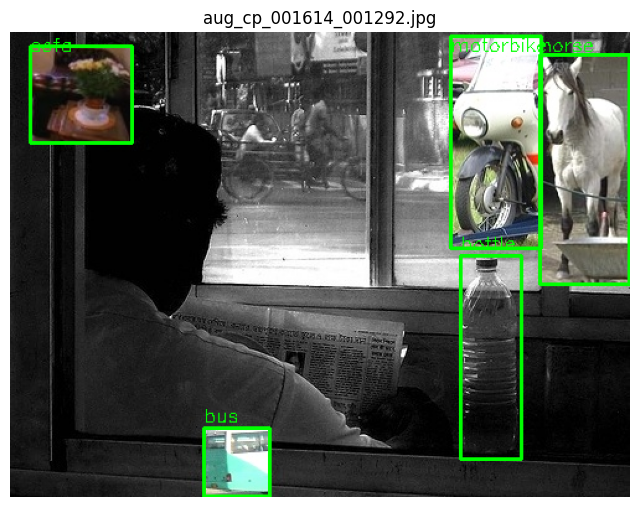

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

txt_path = AUG_TRAINING_DATA_PATH
img_dir = AUG_TRAINING_IMAGE_DIR

with open(txt_path, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

line = random.choice(lines) # pic random
parts = line.split()

filename = parts[0]
nums = list(map(float, parts[1:]))

# === Load image ===
img_path = img_dir + filename
img = cv2.imread(img_path)
if img is None:
    raise FileNotFoundError(f"Image not found: {img_path}")

# draw bounding box
for i in range(0, len(nums), 5):
    xmin, ymin, xmax, ymax, cls = map(int, nums[i:i+5])
    color = (0, 255, 0)
    cv2.rectangle(img, (xmin, ymin), (xmax, ymax), color, 2)
    label = class_name_list[int(cls)] if int(cls) < len(class_name_list) else str(cls)
    cv2.putText(img, label, (xmin, max(15, ymin-5)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

# Convert BGR→RGB for matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === Show image ===
plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title(filename)
plt.axis("off")
plt.show()


## 3.3 Define Data loader

In [ ]:
class DatasetGenerator:
    def __init__(self):
        self.image_name_list = []
        self.record_list = []
        self.object_num_list = []

        fin = open(AUG_TRAINING_DATA_PATH, 'r')
        for line in fin:
            tokens = line.strip().split(' ')
            self.image_name_list.append(tokens[0])

            record = [float(num) for num in tokens[1:]]
            # make each entry has fixed shape (MAX_OBJECTS_PER_IMAGE)
            if len(record) < MAX_OBJECTS_PER_IMAGE * PER_RECORD_LEN: # pad 0
                record = record + [0., 0., 0., 0., 0.] * (MAX_OBJECTS_PER_IMAGE - len(record) // PER_RECORD_LEN)
            elif len(record) > MAX_OBJECTS_PER_IMAGE * PER_RECORD_LEN: # crop
                record = record[:MAX_OBJECTS_PER_IMAGE * PER_RECORD_LEN]
            self.record_list.append(record)

            self.object_num_list.append(min(len(tokens[1:]) // PER_RECORD_LEN, MAX_OBJECTS_PER_IMAGE))
        fin.close()

    def _data_preprocess(self, image_name, record, object_num):
        image_file = tf.io.read_file(AUG_TRAINING_IMAGE_DIR + image_name)
        image = tf.io.decode_jpeg(image_file, channels=3)

        h = tf.shape(image)[0]
        w = tf.shape(image)[1]

        width_ratio = IMAGE_SIZE * 1.0 / tf.cast(w, tf.float32)
        height_ratio = IMAGE_SIZE * 1.0 / tf.cast(h, tf.float32)
        # resize and normalized
        image = tf.image.resize(image, size=[IMAGE_SIZE, IMAGE_SIZE])
        image = input_preprocessor(image)

        record = tf.cast(tf.reshape(record, [-1, PER_RECORD_LEN]), tf.float32)

        xmin = record[:, 0]
        ymin = record[:, 1]
        xmax = record[:, 2]
        ymax = record[:, 3]
        class_idx = record[:, 4]

        xcenter = (xmin + xmax) / 2.0 * width_ratio
        ycenter = (ymin + ymax) / 2.0 * height_ratio
        box_w = (xmax - xmin) * width_ratio
        box_h = (ymax - ymin) * height_ratio

        labels = tf.stack([xcenter, ycenter, box_w, box_h, class_idx], axis=1) # all object

        return image, labels, tf.cast(object_num, tf.int32)

    def generate(self):
        dataset = tf.data.Dataset.from_tensor_slices((self.image_name_list,
                                                      np.array(self.record_list),
                                                      np.array(self.object_num_list)))
        dataset = dataset.shuffle(100000)\
                         .map(self._data_preprocess, num_parallel_calls=tf.data.experimental.AUTOTUNE)\
                         .batch(BATCH_SIZE, drop_remainder=True)\
                         .prefetch(tf.data.experimental.AUTOTUNE)
                         # add drop_remainder to ensure same size in each batch
        return dataset

# 4. Models

## 4.1 Define model structure

In [ ]:
# part I: feature extractor (Backbone)

feature_extractor = tf.keras.applications.densenet.DenseNet121(include_top=False, weights='imagenet')
input_preprocessor = tf.keras.applications.densenet.preprocess_input

In [ ]:
# part II: detect heads

# define one cnn layer
def conv_leaky_relu(inputs, filters, size, stride):
    x = layers.Conv2D(filters, size, stride, padding='same')(inputs)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.BatchNormalization()(x)
    return x

# define cnn structure
    # input
img_inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
x = feature_extractor(img_inputs)

    # detect layer
x = conv_leaky_relu(x, 1024, 3, 1)
x = conv_leaky_relu(x, 1024, 3, 2)

x = conv_leaky_relu(x, 1024, 3, 1)
x = conv_leaky_relu(x, 1024, 3, 1)

    # output layer (full connected) (S×S×(C + B + B×4))
x = layers.Flatten()(x)
x = layers.Dense(4096, kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01))(x)
x = layers.LeakyReLU(0.1)(x)
outputs = layers.Dense(CELL_SIZE * CELL_SIZE * (NUM_CLASSES + BOXES_PER_CELL + BOXES_PER_CELL * 4),
                       kernel_initializer=tf.keras.initializers.TruncatedNormal(stddev=0.01))(x)

# wrap into a keras model
YOLO = keras.Model(inputs=img_inputs, outputs=outputs, name='YOLO')

# check the summary
YOLO.summary()

Model: "YOLO"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 448, 448, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 14, 14, 1024)   │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 1024)   │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 14, 14, 1024)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 1024)   │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 1024)     │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 1024)     │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 1024)     │     9,438,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 7, 7, 1024)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 7, 7, 1024)     │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   205,524,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1470)           │     6,022,590 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,354,302 (977.91 MB)

 Trainable params: 256,262,462 (977.56 MB)

 Non-trainable params: 91,840 (358.75 KB)

## 4.2 Define Loss

same as TA's yolo-1 loss definition

In [ ]:
# base boxes (for loss calculation)
base_boxes = np.zeros([CELL_SIZE, CELL_SIZE, 4])

# initializtion for each cell
for y in range(CELL_SIZE):
    for x in range(CELL_SIZE):
        base_boxes[y, x, :] = [IMAGE_SIZE / CELL_SIZE * x, IMAGE_SIZE / CELL_SIZE * y, 0, 0]

base_boxes = np.resize(base_boxes, [CELL_SIZE, CELL_SIZE, 1, 4])
base_boxes = np.tile(base_boxes, [1, 1, BOXES_PER_CELL, 1])


def iou(boxes1, boxes2):
    '''calculate ious
    Args:
      boxes1: 4-D tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL, 4]  ====> (x_center, y_center, w, h)
      boxes2: 1-D tensor [4] ===> (x_center, y_center, w, h)

    Return:
      iou: 3-D tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
      ====> iou score for each cell
    '''

    # boxes1 : [4(xmin, ymin, xmax, ymax), cell_size, cell_size, boxes_per_cell]
    boxes1 = tf.stack([boxes1[:, :, :, 0] - boxes1[:, :, :, 2] / 2, boxes1[:, :, :, 1] - boxes1[:, :, :, 3] / 2,
                      boxes1[:, :, :, 0] + boxes1[:, :, :, 2] / 2, boxes1[:, :, :, 1] + boxes1[:, :, :, 3] / 2])

    # boxes1 : [cell_size, cell_size, boxes_per_cell, 4(xmin, ymin, xmax, ymax)]
    boxes1 = tf.transpose(boxes1, [1, 2, 3, 0])

    boxes2 = tf.stack([boxes2[0] - boxes2[2] / 2, boxes2[1] - boxes2[3] / 2,
                       boxes2[0] + boxes2[2] / 2, boxes2[1] + boxes2[3] / 2])

    # calculate the left up point of boxes' overlap area
    lu = tf.maximum(boxes1[:, :, :, 0:2], boxes2[0:2])
    # calculate the right down point of boxes overlap area
    rd = tf.minimum(boxes1[:, :, :, 2:], boxes2[2:])

    # intersection
    intersection = rd - lu

    # the size of the intersection area
    inter_square = intersection[:, :, :, 0] * intersection[:, :, :, 1]
    mask = tf.cast(intersection[:, :, :, 0] > 0, tf.float32) * tf.cast(intersection[:, :, :, 1] > 0, tf.float32)

    # if intersection is negative, then the boxes don't overlap
    inter_square = mask * inter_square

    # calculate the boxs1 square and boxs2 square
    square1 = (boxes1[:, :, :, 2] - boxes1[:, :, :, 0]) * (boxes1[:, :, :, 3] - boxes1[:, :, :, 1])
    square2 = (boxes2[2] - boxes2[0]) * (boxes2[3] - boxes2[1])

    return inter_square/(square1 + square2 - inter_square + 1e-6)


def losses_calculation(predict, label):
    '''
    calculate loss
    Args:
      predict: 3-D tensor [cell_size, cell_size, num_classes + 5 * boxes_per_cell]
      label :  [1, 5]  (x_center, y_center, w, h, class)
    '''
    label = tf.reshape(label, [-1])

    # Step A. calculate objects tensor [CELL_SIZE, CELL_SIZE]
    # turn pixel position into cell position (corner)
    min_x = (label[0] - label[2] / 2) / (IMAGE_SIZE / CELL_SIZE)
    max_x = (label[0] + label[2] / 2) / (IMAGE_SIZE / CELL_SIZE)

    min_y = (label[1] - label[3] / 2) / (IMAGE_SIZE / CELL_SIZE)
    max_y = (label[1] + label[3] / 2) / (IMAGE_SIZE / CELL_SIZE)

    min_x = tf.floor(min_x)
    min_y = tf.floor(min_y)

    max_x = tf.minimum(tf.math.ceil(max_x), CELL_SIZE)
    max_y = tf.minimum(tf.math.ceil(max_y), CELL_SIZE)

    # calculate mask of object with cells
    onset = tf.cast(tf.stack([max_y - min_y, max_x - min_x]), dtype=tf.int32)
    object_mask = tf.ones(onset, tf.float32)

    offset = tf.cast(tf.stack([min_y, CELL_SIZE - max_y, min_x, CELL_SIZE - max_x]), tf.int32)
    offset = tf.reshape(offset, (2, 2))
    object_mask = tf.pad(object_mask, offset, 'CONSTANT')

    # Step B. calculate the coordination of object center and the corresponding mask
    # turn pixel position into cell position (center)
    center_x = label[0] / (IMAGE_SIZE / CELL_SIZE)
    center_x = tf.floor(center_x)
    center_y = label[1] / (IMAGE_SIZE / CELL_SIZE)
    center_y = tf.floor(center_y)
    response = tf.ones([1, 1], tf.float32)

    # calculate the coordination of object center with cells
    objects_center_coord = tf.cast(tf.stack([center_y, CELL_SIZE - center_y - 1,
                                             center_x, CELL_SIZE - center_x - 1]),
                                   tf.int32)
    objects_center_coord = tf.reshape(objects_center_coord, (2, 2))

    # make mask
    response = tf.pad(response, objects_center_coord, 'CONSTANT')

    # Step C. calculate iou_predict_truth [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    predict_boxes = predict[:, :, NUM_CLASSES + BOXES_PER_CELL:]

    predict_boxes = tf.reshape(predict_boxes, [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL, 4])
    # cell position to pixel position
    predict_boxes = predict_boxes * [IMAGE_SIZE / CELL_SIZE, IMAGE_SIZE / CELL_SIZE, IMAGE_SIZE, IMAGE_SIZE]

    # if there's no predict_box in that cell, then the base_boxes will be calcuated with label and got iou equals 0
    predict_boxes = base_boxes + predict_boxes

    iou_predict_truth = iou(predict_boxes, label[0:4])

    # calculate C tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    C = iou_predict_truth * tf.reshape(response, [CELL_SIZE, CELL_SIZE, 1])

    # calculate I tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    I = iou_predict_truth * tf.reshape(response, [CELL_SIZE, CELL_SIZE, 1])

    max_I = tf.reduce_max(I, 2, keepdims=True)

    # replace large iou scores with response (object center) value
    I = tf.cast((I >= max_I), tf.float32) * tf.reshape(response, (CELL_SIZE, CELL_SIZE, 1))

    # calculate no_I tensor [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    no_I = tf.ones_like(I, dtype=tf.float32) - I

    p_C = predict[:, :, NUM_CLASSES:NUM_CLASSES + BOXES_PER_CELL]

    # calculate truth x, y, sqrt_w, sqrt_h 0-D
    x = label[0]
    y = label[1]

    sqrt_w = tf.sqrt(tf.abs(label[2]))
    sqrt_h = tf.sqrt(tf.abs(label[3]))

    # calculate predict p_x, p_y, p_sqrt_w, p_sqrt_h 3-D [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL]
    p_x = predict_boxes[:, :, :, 0]
    p_y = predict_boxes[:, :, :, 1]

    p_sqrt_w = tf.sqrt(tf.minimum(IMAGE_SIZE * 1.0, tf.maximum(0.0, predict_boxes[:, :, :, 2])))
    p_sqrt_h = tf.sqrt(tf.minimum(IMAGE_SIZE * 1.0, tf.maximum(0.0, predict_boxes[:, :, :, 3])))

    # calculate ground truth p 1-D tensor [NUM_CLASSES]
    P = tf.one_hot(tf.cast(label[4], tf.int32), NUM_CLASSES, dtype=tf.float32)

    # calculate predicted p_P 3-D tensor [CELL_SIZE, CELL_SIZE, NUM_CLASSES]
    p_P = predict[:, :, 0:NUM_CLASSES]

    # class_loss
    class_loss = tf.nn.l2_loss(tf.reshape(object_mask, (CELL_SIZE, CELL_SIZE, 1)) * (p_P - P)) * CLASS_SCALE

    # object_loss
    object_loss = tf.nn.l2_loss(I * (p_C - C)) * OBJECT_SCALE

    # noobject_loss
    noobject_loss = tf.nn.l2_loss(no_I * (p_C)) * NOOBJECT_SCALE

    # coord_loss
    coord_loss = (tf.nn.l2_loss(I * (p_x - x) / (IMAGE_SIZE / CELL_SIZE)) +
                  tf.nn.l2_loss(I * (p_y - y) / (IMAGE_SIZE / CELL_SIZE)) +
                  tf.nn.l2_loss(I * (p_sqrt_w - sqrt_w)) / IMAGE_SIZE +
                  tf.nn.l2_loss(I * (p_sqrt_h - sqrt_h)) / IMAGE_SIZE) * COORD_SCALE

    return class_loss + object_loss + noobject_loss + coord_loss

In [ ]:
def yolo_loss_map(predicts, labels, objects_num):
    '''
    Add Loss to all the trainable variables
    Args:
        predicts:    4-D tensor [batch_size, cell_size, cell_size, num_classes + 5 * boxes_per_cell]
                     ===> (num_classes, boxes_per_cell, 4 * boxes_per_cell)
        labels:      3-D tensor of [batch_size, max_objects, 5]
        objects_num: 1-D tensor [batch_size]
    '''
    def get_loss(i):
        predict = predicts[i, :, :, :]
        label = labels[i, :, :]
        object_num = objects_num[i]

        loss = 0.
        for j in tf.range(object_num):
            loss = loss + losses_calculation(predict, label[j:j+1, :])
        return loss
    # parallel with tf.map_fn to speed up
    batch_loss = tf.map_fn(fn=get_loss, elems=tf.range(BATCH_SIZE), fn_output_signature=tf.float32)
    return tf.reduce_mean(batch_loss)

# 5. Training

## 5.1 Prepare for training

In [ ]:
# data generate
dataset = DatasetGenerator().generate()

# learning reate and optimizer
LEARNING_RATE = 2e-5
optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
train_loss_metric = tf.keras.metrics.Mean(name='loss')

# optimizer = tf.keras.optimizers.AdamW(learning_rate=5e-5, weight_decay=1e-4 )

In [ ]:
@tf.function
def train_step(image, labels, objects_num):
    with tf.GradientTape() as tape:
        outputs = YOLO(image)
        class_end = CELL_SIZE * CELL_SIZE * NUM_CLASSES
        conf_end = class_end + CELL_SIZE * CELL_SIZE * BOXES_PER_CELL
        class_probs = tf.reshape(outputs[:, 0:class_end], (-1, CELL_SIZE, CELL_SIZE, NUM_CLASSES))
        confs = tf.reshape(outputs[:, class_end:conf_end], (-1, CELL_SIZE, CELL_SIZE, BOXES_PER_CELL))
        boxes = tf.reshape(outputs[:, conf_end:], (-1, CELL_SIZE, CELL_SIZE, BOXES_PER_CELL * 4))
        predicts = tf.concat([class_probs, confs, boxes], 3)

        loss = yolo_loss_map(predicts, labels, objects_num) # use loss_map
        train_loss_metric(loss)

    grads = tape.gradient(loss, YOLO.trainable_weights)
    optimizer.apply_gradients(zip(grads, YOLO.trainable_weights))

In [ ]:
ck_path = "./ckpts/YOLO"
ckpt = tf.train.Checkpoint(epoch=tf.Variable(0), net=YOLO)
manager = tf.train.CheckpointManager(ckpt, ck_path, max_to_keep=10, checkpoint_name='yolo')


start_epoch = 0
if manager.latest_checkpoint:
    start_epoch = int(manager.latest_checkpoint.split('-')[-1])
    ckpt.restore(manager.latest_checkpoint)
    print(manager.latest_checkpoint)

## 5.2 Run training

In [ ]:
from tqdm import tqdm
from datetime import datetime

EPOCHS = 30
print(f'{datetime.now()}, start training.')
for i in range(start_epoch, EPOCHS):
    train_loss_metric.reset_state()
    ckpt.epoch.assign_add(1)

    for idx, (image, labels, objects_num) in enumerate(tqdm(dataset)):
        train_step(image, labels, objects_num)

    print(f'{datetime.now()}, Epoch {i+1}: loss {train_loss_metric.result():.2f}')

    save_path = manager.save()
    print(f'Saved checkpoint for epoch {int(ckpt.epoch)}: {save_path}')

2025-11-15 17:18:02.300076, start training.


  0%|          | 0/4127 [00:00<?, ?it/s]2025-11-15 17:18:19.866110: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91500
2025-11-15 17:18:22.070612: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.33GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-15 17:18:22.095500: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.27GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-15 17:18:22.168825: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 4.33GiB with freed_by_count=0. The caller indicates that this is

2025-11-15 17:30:27.415305, Epoch 1: loss 4.98
Saved checkpoint for epoch 1: ./ckpts/YOLO/yolo-1


100%|██████████| 4127/4127 [12:04<00:00,  5.70it/s]


2025-11-15 17:42:33.194582, Epoch 2: loss 2.73
Saved checkpoint for epoch 2: ./ckpts/YOLO/yolo-2


...

2025-11-15 22:56:47.433513, Epoch 28: loss 1.11
Saved checkpoint for epoch 28: ./ckpts/YOLO/yolo-28


100%|██████████| 4127/4127 [12:04<00:00,  5.70it/s]


2025-11-15 23:08:52.398280, Epoch 29: loss 1.09
Saved checkpoint for epoch 29: ./ckpts/YOLO/yolo-29


100%|██████████| 4127/4127 [12:03<00:00,  5.70it/s]


2025-11-15 23:20:57.276031, Epoch 30: loss 1.06
Saved checkpoint for epoch 30: ./ckpts/YOLO/yolo-30


# 6. Run Test data

## 6.1 Inference model for test data

In [ ]:

# 1. I/O
test_image_name_list = []
with open(TESTING_DATA_PATH, 'r') as fin:
    for line in fin:
        test_image_name_list.append(line.strip().split()[0])
def load_img_data(image_name):
    image_file = tf.io.read_file(TESTING_IMAGE_DIR + image_name)
    image = tf.image.decode_jpeg(image_file, channels=3)
    h = tf.shape(image)[0]
    w = tf.shape(image)[1]
    image = tf.image.resize(image, size=[IMAGE_SIZE, IMAGE_SIZE])
    image = input_preprocessor(image) # model feature extractor
    return image_name, image, h, w

# 2. load test dataset
test_dataset = tf.data.Dataset.from_tensor_slices(test_image_name_list)\
                              .map(load_img_data, num_parallel_calls=tf.data.experimental.AUTOTUNE)\
                              .batch(32)\
                              .prefetch(tf.data.AUTOTUNE)

# 3. restore checkpoint
ck_path = "./ckpts/YOLO"
ckpt = tf.train.Checkpoint(epoch=tf.Variable(0), net=YOLO)
manager = tf.train.CheckpointManager(ckpt, ck_path, max_to_keep=10, checkpoint_name='yolo')

if manager.latest_checkpoint:
    ckpt.restore(manager.latest_checkpoint)
    print(manager.latest_checkpoint)

# 4. inference using trained model
@tf.function
def prediction_step(img):
    return YOLO(img, training=False)

./ckpts/YOLO/yolo-30


## 6.2 Get the bounding box and write to .txt

In [ ]:
def process_outputs(outputs):
    '''
    Process YOLO outputs into bou
    '''

    class_end = CELL_SIZE * CELL_SIZE * NUM_CLASSES
    conf_end = class_end + CELL_SIZE * CELL_SIZE * BOXES_PER_CELL
    class_probs = np.reshape(outputs[:, 0:class_end], (-1, CELL_SIZE, CELL_SIZE, NUM_CLASSES))
    confs = np.reshape(outputs[:, class_end:conf_end], (-1, CELL_SIZE, CELL_SIZE, BOXES_PER_CELL))
    boxes = np.reshape(outputs[:, conf_end:], (-1, CELL_SIZE, CELL_SIZE, BOXES_PER_CELL * 4))
    predicts = np.concatenate([class_probs, confs, boxes], 3)

    p_classes = predicts[0, :, :, :NUM_CLASSES]
    C = predicts[0, :, :, NUM_CLASSES:NUM_CLASSES+BOXES_PER_CELL]
    coordinate = predicts[0, :, :, NUM_CLASSES+BOXES_PER_CELL:]

    p_classes = np.reshape(p_classes, (CELL_SIZE, CELL_SIZE, 1, NUM_CLASSES))
    C = np.reshape(C, (CELL_SIZE, CELL_SIZE, BOXES_PER_CELL, 1))

    P = C * p_classes
    # P's shape [CELL_SIZE, CELL_SIZE, BOXES_PER_CELL, NUM_CLASSES]

    xmin, ymin, xmax, ymax, class_num, conf = [], [], [], [], [], []

    max_conf_idx = np.unravel_index(np.argmax(P), P.shape)
    threshold = P[max_conf_idx] * 0.5

    for i in range(np.prod(P.shape)):
        idx = np.unravel_index(i, P.shape)
        if (P[idx] > threshold):
            class_num.append(idx[3])
            conf.append(P[idx])

            coordinate = np.reshape(coordinate, (CELL_SIZE, CELL_SIZE, BOXES_PER_CELL, 4))
            xcenter, ycenter, w, h = coordinate[idx[0], idx[1], idx[2], :]

            xcenter = (idx[1] + xcenter) * (IMAGE_SIZE / float(CELL_SIZE))
            ycenter = (idx[0] + ycenter) * (IMAGE_SIZE / float(CELL_SIZE))

            w = w * IMAGE_SIZE
            h = h * IMAGE_SIZE

            xmin.append(xcenter - w / 2.0)
            ymin.append(ycenter - h / 2.0)

            xmax.append(xmin[-1] + w)
            ymax.append(ymin[-1] + h)

    return xmin, ymin, xmax, ymax, class_num, conf


with open('./test_prediction.txt', 'w') as fout:
    for img_name, test_img, img_h, img_w in test_dataset:
        batch_num = img_name.shape[0]
        for i in range(batch_num):
            xmin, ymin, xmax, ymax, class_num, conf = process_outputs(prediction_step(test_img[i:i+1]))
            for j in range(len(xmin)):
                xmin[j] = xmin[j] * (img_w[i] / IMAGE_SIZE)
                ymin[j] = ymin[j] * (img_h[i] / IMAGE_SIZE)
                xmax[j] = xmax[j] * (img_w[i] / IMAGE_SIZE)
                ymax[j] = ymax[j] * (img_h[i] / IMAGE_SIZE)
                fout.write(img_name[i].numpy().decode('ascii')+' %d %d %d %d %d %f\n' % (
                    xmin[j], ymin[j], xmax[j], ymax[j], class_num[j], conf[j]))

2025-11-15 23:42:51.332250: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-11-15 23:42:51.386005: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.34GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


## 6.3 Evaluate test .txt file and Generate output_file

In [ ]:
# evaluate
import sys
sys.path.insert(0, './dataset/evaluate')
import evaluate
import pandas as pd
evaluate.evaluate('./test_prediction.txt', './output_file.csv')

# output file
cap = pd.read_csv('./output_file.csv')['packedCAP']
print('score: {:f}'.format(sum((1. - cap) ** 2) / len(cap)))

End Evalutation
score: 0.408309


: 

# 7. Report


###  1. Data Augmentation (3.1)

我們用offline處理data augmentation，也就是用另外的.py檔產生新的一組.txt, images資料。(詳細可參考Appendix)

Problem of the imbalance:  
一開始在資料處理的時候，”human class"有5000多，佔34%左右，car, chair大概9%，其餘的都佔不到5%，imbalance會讓模型訓練的時候偏好數量較多的class。

How we pre-process the data ?  
-  為了避免模型學習到畫質太低或是只有部分結構的圖片，我們篩掉bounding box太小的(w or h <1/10)，且只有把labels刪掉，但沒有去處理圖片
-  用三個model augmenat the data:   
mosaic (選random 4 圖片組成 2*2)  
copy and paste(cropped the rare classes to paste to over classes-> 為了新增bounding box外圍背景的多樣性)     
simple (採用flip 或rotate copy原本的照片)  
-  在augment這些rare class之後,再檢查cap 每個 class數量在 3000

### 2. Model - Feature Extractor (Backbone) (4.1)
#### 2.1 Feature extractor (Backbone) - Extracts feature maps from raw images

我嘗試 DenseNet121 and MobileNetV2(Fast, with medium accuracy). 在30 epochs之後，兩者有一樣的loss，但DenseNet121 的evaluate比MobileNetV2還好，最終使用DenseNet121。

我們也許可以再多嘗試其他的backbone model，像是 ResNet50V2, and EfficientNetB0/B1, 也許可以更加提升accuracy

#### 2.2 Detection Head - Transforms features into box + class predictions
我們有嘗試實作YOLOv4，但最後失敗了，所以最後使用YOLO v1，以下是我們的模型架構以及loss function還有可能的失敗原因:

**Model structure**:   
* Backbone:能夠增加 CNN 的學習能力，即便將模型輕量化，也能保持準確性。我們一開始實作與論文相同的CSPDarknet53，但因為訓練效果不佳，我們認為可能是沒有pretrained weight原因，因此也嘗試了採用keras支援的ResNet50，使用ImageNet pretrained的weight，但依舊失敗。
* Neck : 能夠擴大Receptive field以及融合不同尺度feature map 的訊息，採用與論文相同的PAN/FPN。
* Head :採用與YOLOv3相同的head。

**Loss Function** :   
* Bounding box loss : ​採用CIoU，同時考慮 IoU、中心距與寬高比，較 L1/L2 更適合。
* Objectness loss : 採用Binary Cross-Entropy（BCE)
* Classification loss:採用Binary Cross-Entropy（BCE)，並搭配Label Smoothing以減少overfitting與sharp gradients。

**Reason for failure** :   
* Dataset: 我們在做Copy and Paste時只有剪下bounding box沒有做去背，加上貼上的邏輯可能設計不良，導致訓練效果不佳；Augmentations不佳或不足。
* Model: Backbone 沒有pretrained weight，我們後來搜尋其他人的實作經驗後發現這樣成功機率極低，但後來改成ImageNet pretrained的ResNet50也沒有好轉，因此可能還有其他沒有察覺的因素。
* Training stage: 我們參考其他人實做YOLOv4的程式時發現warm-up的步驟是必須的，才能有穩定的訓練結果，但後來沒有時間重新進行訓練。
* Other reasons: 可能是我們程式沒寫好、資料轉好沒做好等沒有發現的原因。


### 3. Get the bounding box (6.2)
我們改成產生多個bounding box,並且只用圖片中confidence score最大的取0.5當成輸出

Problem occured:

找到output bounding box的比例很花時間，並且不同設定下的threshold差異也很大。

How to solve:
用圖片中confidence score最大的取0.5當成輸出

### 4. Conclusion
在這次的competition中，我們發現了data augmentation及data balancing的重要性，對dataset進行處理後，相同的模型結果卻進步許多；而model本身的架構也差很多，我們在研究時發現後續的YOLO新增了不少設計，使得預測結果更好，因此我們也嘗試了實作YOLOv4，雖然最後失敗了，但也學到了YOLOv4的架構集能夠提升準確度的原因，總而言之，最後依然有通過TA80的門檻還是非常有成就感，也對物件偵測模型有更多的了解。

# 8. Appendix

## attempt code for YOLO-v4

In [ ]:
RUN_CODE = False

if RUN_CODE:
    ''' Layers and building blocks'''
    class Mish(layers.Layer):
        def call(self, x):
            return x * tf.math.tanh(tf.math.softplus(x))

    def CBL(x, f, k, s=1, use_mish=True, name=None):
        x = layers.Conv2D(f, k, s, padding='same', use_bias=False,
                        kernel_initializer='he_normal', name=None if name is None else name+'/conv')(x)
        x = layers.BatchNormalization(name=None if name is None else name+'/bn')(x)
        x = Mish(name=None if name is None else name+'/mish')(x) if use_mish else layers.LeakyReLU(0.1)(x)
        return x

    def ResidualBlock(x, ch, use_mish=True, name=None):
        sc = x
        y = CBL(x, ch, 1, use_mish=use_mish, name=None if name is None else name+'/cv1')
        y = CBL(y, ch, 3, use_mish=use_mish, name=None if name is None else name+'/cv2')
        return layers.Add(name=None if name is None else name+'/add')([sc, y])

    def CSPStage(x, filters, n_blocks, use_mish=True, name=None):
        x = CBL(x, filters, 3, s=2, use_mish=use_mish, name=None if name is None else name+'/down')
        c1 = CBL(x, filters//2, 1, use_mish=use_mish, name=None if name is None else name+'/split1')
        c2 = CBL(x, filters//2, 1, use_mish=use_mish, name=None if name is None else name+'/split2')
        y = c2
        ch = y.shape[-1]
        for i in range(n_blocks):
            y = ResidualBlock(y, ch, use_mish=use_mish, name=None if name is None else f'{name}/res{i}')
        y = CBL(y, filters//2, 1, use_mish=use_mish, name=None if name is None else name+'/post')
        out = layers.Concatenate(name=None if name is None else name+'/concat')([y, c1])
        out = CBL(out, filters, 1, use_mish=use_mish, name=None if name is None else name+'/fuse')
        return out

    def SPP(x, name=None):
        p1 = layers.MaxPool2D(pool_size=5, strides=1, padding='same')(x)
        p2 = layers.MaxPool2D(pool_size=9, strides=1, padding='same')(x)
        p3 = layers.MaxPool2D(pool_size=13, strides=1, padding='same')(x)
        return layers.Concatenate()([p3,p2,p1,x])

    class PointWiseSAM(layers.Layer):
        def __init__(self, **kw): super().__init__(**kw); self.conv = layers.Conv2D(1,1,padding='same',activation='sigmoid')
        def call(self, x): return x * self.conv(x)

    def upsample(x, scale=2):
        h = tf.shape(x)[1]; w = tf.shape(x)[2]
        return tf.image.resize(x, (h*scale, w*scale), method='nearest')

    class MiWRC(layers.Layer):
        def __init__(self, eps=1e-4, **kw): super().__init__(**kw); self.eps = eps
        def build(self, input_shape):
            n = len(input_shape)
            self.ws = self.add_weight('w', shape=(n,), initializer='ones', trainable=True)
            c = input_shape[0][-1]
            self.proj = [None if s[-1]==c else layers.Conv2D(c,1,padding='same') for s in input_shape]
            super().build(input_shape)
        def call(self, xs):
            w = tf.nn.relu(self.ws); w = w/(tf.reduce_sum(w)+self.eps)
            xs = [xi if pj is None else pj(xi) for xi,pj in zip(xs,self.proj)]
            return tf.add_n([w[i]*xs[i] for i in range(len(xs))])

    '''Backbone'''
    def CSPDarknet53(inp):
        x = CBL(inp, 32, 3)
        x = CSPStage(x, 64, 1, name='csp1')
        x = CSPStage(x, 128, 2, name='csp2')
        c3 = CSPStage(x, 256, 8, name='csp3')
        c4 = CSPStage(c3, 512, 8, name='csp4')
        c5 = CSPStage(c4, 1024, 4, name='csp5')
        return c3, c4, c5
    '''Neck: SPP + PAN (concat)'''
    def YOLOv4_neck(c3, c4, c5):
        p5 = CBL(c5, 512, 1)
        p5 = CBL(p5, 1024, 3)
        p5 = CBL(p5, 512, 1)
        p5 = SPP(p5)
        p5 = CBL(p5, 512, 1)
        p5 = CBL(p5, 1024, 3)
        p5 = CBL(p5, 512, 1)

        p5_up = layers.Lambda(lambda t: upsample(t))(p5)
        p4_in = CBL(c4, 512, 1)
        p4 = layers.Concatenate()([p4_in, p5_up])
        p4 = CBL(p4, 512, 1)
        p4 = CBL(p4, 1024, 3)
        p4 = CBL(p4, 512, 1)
        p4 = PointWiseSAM()(p4)

        p4_up = layers.Lambda(lambda t: upsample(t))(p4)
        p3_in = CBL(c3, 256, 1)
        p3 = layers.Concatenate()([p3_in, p4_up])
        p3 = CBL(p3, 256, 1)
        p3 = CBL(p3, 512, 3)
        p3 = CBL(p3, 256, 1)
        p3 = PointWiseSAM()(p3)

        p3_down = CBL(p3, 512, 3, s=2)
        p4 = MiWRC(name='fuse_p4')([p3_down, p4])
        p4 = CBL(p4, 512, 1)
        p4 = CBL(p4, 1024, 3)
        p4 = CBL(p4, 512, 1)
        p4_down = CBL(p4, 1024, 3, s=2)
        p5 = MiWRC(name='fuse_p5')([p4_down, p5])
        p5 = CBL(p5, 512, 1)
        p5 = CBL(p5, 1024, 3)
        p5 = CBL(p5, 512, 1)
        return p3, p4, p5

    '''Head: YOLO head'''
    def yolo_head(x, nA, nC, mid_channels=None, name=None):
        if mid_channels is None:
            mid_channels = 256 if x.shape[-1] is None else max(
                64, int(x.shape[-1]))
        y = CBL(x, mid_channels, 3, name=None if name is None else name+'/cv3x3')
        y = layers.Conv2D(nA*(nC+5), 1, 1, padding='same', kernel_initializer='glorot_uniform',
                        name=None if name is None else name+'/pred')(y)
        return y

    '''Build YOLOv4 Model'''
    def build_yolov4(input_shape=(IMAGE_SIZE,IMAGE_SIZE,3), num_classes=NUM_CLASSES):
        inp = layers.Input(shape=input_shape)
        c3,c4,c5 = CSPDarknet53(inp)
        p3,p4,p5 = YOLOv4_neck(c3,c4,c5)
        y_l = yolo_head(p5, 3, num_classes, name='yolo_l')
        y_m = yolo_head(p4, 3, num_classes, name='yolo_m')
        y_s = yolo_head(p3, 3, num_classes, name='yolo_s')
        model = models.Model(inp, [y_l,y_m,y_s], name='YOLOv4')
        model.anchors = tf.constant(ANCHORS, tf.float32)
        model.anchor_masks = ANCHOR_MASKS
        model.num_classes = num_classes
        return model

## generating data augmentation code

In [ ]:
RUN_AUG = False

if RUN_AUG:
    #!/usr/bin/env python3
    # -*- coding: utf-8 -*-
    """
    balance_yolo_dataset.py
    Fully-balanced; supports 3 augmentation modes with adjustable ratios:
    - Mosaic (aug_m_XXXX.jpg)
    - Copy-Paste (aug_cp_XXXX.jpg)
    - Simple geometric/color aug on ORIGINAL images only (aug_s_XXXX.jpg)

    Output:
    - Final images: OUT_IMG_DIR_FINAL
    - Final labels: OUT_DATA_TXT_FINAL (YOLO-v1 style: fname x1 y1 x2 y2 cls ...)

    Notes:
    - 保守的 bbox 檢查與邊界裁切（clamp）已內建。
    - Simple Aug 只針對原始圖，不對前面產生的 aug 圖再疊加。
    - 會自動「cap」各類別到 TARGET_NUM，上限外的 bbox 不會寫入 TXT。
    - 新增「可調 bbox 最小尺寸門檻」：同時支援絕對像素與影像相對比例，兩者「取最大」作為實際門檻。
    """

    import os
    import cv2
    import shutil
    import random
    import math
    import numpy as np
    from collections import defaultdict, Counter

    # =========================
    # CONFIG
    # =========================
    # 原始資料
    DATA_PATH     = "./dataset/pascal_voc_training_data.txt"
    IMAGE_DIR     = "./dataset/VOCdevkit_train/VOC2007/JPEGImages/"

    # 暫存/輸出
    OUT_IMG_DIR_FINAL  = "./dataset/VOCdevkit_train/VOC2007/JPEGImages_balanced/"
    OUT_DATA_TXT_FINAL = "./dataset/pascal_voc_training_data_balanced.txt"
    TEMP_CROP_DIR      = "./dataset/VOCdevkit_train/VOC2007/JPEGImages_cropped/"

    # 類別與目標
    NUM_CLASSES  = 20
    TARGET_NUM   = 3000                 # 每個 class 目標數量
    RNG_SEED     = 2025
    MAX_TOTAL_AUG_IMAGES = 200000       # 安全上限
    IMAGE_SIZE_MOSAIC = 448             # 最終輸出的視圖基準（Mosaic 會 2x2 格接成 448x448）

    # 三種方式的比例（可自行調整，總和不一定要 1，但比例會依相對比做分配）
    AUG_PROPORTIONS = {
        'mosaic':     0.20,
        'copy_paste': 0.40,
        'simple':     0.40,
    }

    # Copy-Paste 參數
    SAVE_CROPS_FOR_LESS = True
    PASTE_LIMIT_PER_IMAGE = 4
    SCALE_RANGE = (0.6, 1.4)

    # Simple Aug 參數（只對原圖）
    SIMPLE_ROTATE_DEG = (15, 30)  # 會隨機正/負
    SIMPLE_SCALE = (0.85, 1.15)
    SIMPLE_TRANSLATE_FRAC = 0.20
    SIMPLE_SHEAR = 0.15
    SIMPLE_USE_FLIP = True
    SIMPLE_USE_BRIGHTNESS_CONTRAST = True
    SIMPLE_USE_COLOR_TEMP = True
    SIMPLE_USE_BLUR = True
    SIMPLE_USE_NOISE = True

    # Mosaic 邊界條件（保留原有的粗過濾）
    MOSAIC_MIN_BOX_AREA = 500
    MOSAIC_MARGIN = 10

    # =========================
    # 🔧 小框過濾門檻（可調）
    #   - 實際門檻 = max( 絕對像素門檻, 相對比例門檻 * 影像尺寸 )
    #   - 只要任一條件（寬/高/面積）不達，就過濾掉
    # =========================
    MIN_W_PIX      = 4        # 絕對最小寬（像素）
    MIN_H_PIX      = 4        # 絕對最小高（像素）
    MIN_AREA_PIX   = 32       # 絕對最小面積（像素^2）

    MIN_W_FRAC     = 0.02     # 相對最小寬（相對影像寬，例如 0.02 = 2%）
    MIN_H_FRAC     = 0.02     # 相對最小高（相對影像高）
    MIN_AREA_FRAC  = 0.0008   # 相對最小面積（相對影像面積，例如 0.0008 = 0.08%）

    # 針對 Mosaic 可再加強（可關閉）
    MOSAIC_USE_GLOBAL_FILTER = True

    # =========================
    # Utils
    # =========================
    def ensure_empty_dir(d):
        if not d or d == "/" or os.path.abspath(d) == os.path.abspath(IMAGE_DIR):
            raise RuntimeError(f"Refusing to clear dangerous path: {d}")
        if os.path.exists(d):
            shutil.rmtree(d)
        os.makedirs(d, exist_ok=True)

    def clamp_box(x1, y1, x2, y2, w, h):
        x1 = max(0, min(int(round(x1)), w - 1))
        y1 = max(0, min(int(round(y1)), h - 1))
        x2 = max(0, min(int(round(x2)), w - 1))
        y2 = max(0, min(int(round(y2)), h - 1))
        return x1, y1, x2, y2

    def parse_line(line):
        parts = line.strip().split()
        if len(parts) < 6: return None, []
        img = parts[0]
        nums = parts[1:]
        if len(nums) % 5 != 0: return None, []
        boxes = []
        for i in range(0, len(nums), 5):
            try:
                x1 = float(nums[i]);   y1 = float(nums[i+1])
                x2 = float(nums[i+2]); y2 = float(nums[i+3])
                c  = int(float(nums[i+4]))
                boxes.append([x1, y1, x2, y2, c])
            except:
                continue
        return img, boxes

    def write_line(f, img_name, boxes):
        flat = [img_name] + [str(int(v)) for b in boxes for v in b]
        f.write(" ".join(flat) + "\n")

    def _meets_min_size(w, h, W, H):
        """判斷單一框是否達到最小尺寸門檻。"""
        # 絕對門檻
        min_w_abs = float(MIN_W_PIX)
        min_h_abs = float(MIN_H_PIX)
        min_a_abs = float(MIN_AREA_PIX)
        # 相對門檻（轉像素）
        min_w_rel = float(MIN_W_FRAC) * float(W)
        min_h_rel = float(MIN_H_FRAC) * float(H)
        min_a_rel = float(MIN_AREA_FRAC) * float(W) * float(H)
        # 實際門檻取最大
        mw = max(min_w_abs,  min_w_rel)
        mh = max(min_h_abs,  min_h_rel)
        ma = max(min_a_abs,  min_a_rel)
        return (w > mw) and (h > mh) and (w * h > ma)

    def filter_small_boxes(img, boxes):
        """
        在 clamp 後呼叫：過濾掉過小 bbox。
        img: np.ndarray (H,W,3)
        boxes: list of [x1,y1,x2,y2,c]
        """
        if img is None: return []
        H, W = img.shape[:2]
        kept = []
        for x1, y1, x2, y2, c in boxes:
            w = max(0, int(x2) - int(x1))
            h = max(0, int(y2) - int(y1))
            if _meets_min_size(w, h, W, H):
                kept.append([int(x1), int(y1), int(x2), int(y2), int(c)])
        return kept

    def validate_and_clamp_boxes(img, boxes):
        """先 clamp 到圖內，再丟 filter_small_boxes 做尺寸過濾。"""
        if img is None: return []
        H, W = img.shape[:2]
        cleaned = []
        for x1, y1, x2, y2, c in boxes:
            xx1, yy1, xx2, yy2 = clamp_box(x1, y1, x2, y2, W, H)
            if xx2 <= xx1 or yy2 <= yy1:
                continue
            cleaned.append([xx1, yy1, xx2, yy2, int(c)])
        # 再做尺寸過濾
        return filter_small_boxes(img, cleaned)

    # 檔名產生器（分前綴）
    AUG_COUNTER = defaultdict(int)
    def next_name(prefix: str, stem: str, ext: str = ".jpg"):
        AUG_COUNTER[prefix] += 1
        return f"{prefix}{AUG_COUNTER[prefix]:06d}_{stem}{ext}"

    # =========================
    # 讀取原始資料
    # =========================
    print("Loading base list...")
    records = []
    cls_counter = Counter()
    filter_cnt = 0
    with open(DATA_PATH, "r") as f:
        for raw in f:
            img, boxes = parse_line(raw)
            if not img or not boxes: continue
            p = os.path.join(IMAGE_DIR, img)
            if not os.path.exists(p): continue


            # filter out small boxes (< 1/10 of width or height)
            img_cv = cv2.imread(p)
            if img_cv is None:
                continue
            H, W = img_cv.shape[:2]
            filtered_boxes = []
            for x1, y1, x2, y2, c in boxes:
                bw = x2 - x1
                bh = y2 - y1
                if bw < W / 10 or bh < H / 10:
                    filter_cnt += 1
                    continue  # skip small boxes
                filtered_boxes.append([x1, y1, x2, y2, c])
            if not filtered_boxes:
                continue


            records.append((img, boxes))
            for *_, c in boxes:
                cls_counter[int(c)] += 1

    print(f"filter out box counts: {filter_cnt}")
    print("Base counts:")
    for c in range(NUM_CLASSES):
        print(f"{c:02d}: {cls_counter[c]}")

    # =========================
    # 準備輸出資料夾 & 裁剪池
    # =========================
    ensure_empty_dir(OUT_IMG_DIR_FINAL)
    if SAVE_CROPS_FOR_LESS:
        ensure_empty_dir(TEMP_CROP_DIR)

    # 哪些 class 需要補
    needed_per_class = {c: max(0, TARGET_NUM - cls_counter[c]) for c in range(NUM_CLASSES)}
    print("\nNeed per class (to reach TARGET_NUM):")
    for c in range(NUM_CLASSES):
        if needed_per_class[c] > 0:
            print(f"class {c}: +{needed_per_class[c]}")

    # 依需求建立 crops（只為「目前小於目標」的類別存）
    if SAVE_CROPS_FOR_LESS:
        print("\nBuilding crop pool for under-represented classes...")
        crop_pool = defaultdict(list)
        save_count = Counter()
        for img_name, boxes in records:
            img_path = os.path.join(IMAGE_DIR, img_name)
            img = cv2.imread(img_path)
            if img is None: continue
            H, W = img.shape[:2]
            for x1, y1, x2, y2, c in boxes:
                c = int(c)
                if needed_per_class[c] <= 0:  # 不需要補的不裁
                    continue
                xx1, yy1, xx2, yy2 = clamp_box(x1, y1, x2, y2, W, H)
                if xx2 <= xx1 or yy2 <= yy1:
                    continue
                # 這裡也做一次「最小尺寸」過濾，避免產生超小 crop
                if not _meets_min_size(xx2-xx1, yy2-yy1, W, H):
                    continue
                crop = img[yy1:yy2, xx1:xx2]
                if crop.size == 0: continue
                save_count[c] += 1
                out_name = f"{c:02d}_{save_count[c]:05d}.jpg"
                out_path = os.path.join(TEMP_CROP_DIR, out_name)
                cv2.imwrite(out_path, crop)
                crop_pool[c].append(out_path)
        print("Crop pool size per class:")
        for c in range(NUM_CLASSES):
            if needed_per_class[c] > 0:
                print(f"class {c}: {len(crop_pool[c])} crops")

    rng = random.Random(RNG_SEED)
    orig_images = [nm for nm, _ in records]
    records_map = {nm: boxes for nm, boxes in records}

    # =========================
    # 簡單增強（Simple）工具
    # =========================
    def flip_horizontal(image, bboxes):
        h, w = image.shape[:2]
        img_f = cv2.flip(image, 1)
        out = []
        for x1, y1, x2, y2, c in bboxes:
            out.append([w - x2, y1, w - x1, y2, c])
        return img_f, out

    def rotate_image_and_bboxes(image, bboxes, angle):
        h, w = image.shape[:2]
        center = (w / 2, h / 2)
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        img_r = cv2.warpAffine(image, M, (w, h), borderValue=(255, 255, 255))
        out = []
        for x1, y1, x2, y2, c in bboxes:
            pts = np.array([[x1, y1], [x2, y1], [x2, y2], [x1, y2]], dtype=np.float32)
            pts_h = np.hstack([pts, np.ones((4,1), dtype=np.float32)])
            tr = (M @ pts_h.T).T
            xx = tr[:,0]; yy = tr[:,1]
            out.append([xx.min(), yy.min(), xx.max(), yy.max(), c])
        return img_r, out

    def scale_image_and_bboxes(image, bboxes, sx, sy):
        h, w = image.shape[:2]
        nw, nh = int(w * sx), int(h * sy)
        small = cv2.resize(image, (max(1, nw), max(1, nh)))
        canvas = np.ones_like(image) * 255
        x_lim = min(w, small.shape[1]); y_lim = min(h, small.shape[0])
        canvas[:y_lim, :x_lim] = small[:y_lim, :x_lim]
        out = []
        for x1, y1, x2, y2, c in bboxes:
            out.append([x1*sx, y1*sy, x2*sx, y2*sy, c])
        return canvas, out

    def translate_image_and_bboxes(image, bboxes, frac=0.2):
        h, w = image.shape[:2]
        tx = rng.uniform(-w*frac, w*frac)
        ty = rng.uniform(-h*frac, h*frac)
        M = np.float32([[1, 0, tx], [0, 1, ty]])
        img_t = cv2.warpAffine(image, M, (w, h), borderValue=(255,255,255))
        out = []
        for x1, y1, x2, y2, c in bboxes:
            out.append([x1+tx, y1+ty, x2+tx, y2+ty, c])
        return img_t, out

    def shear_image_and_bboxes(image, bboxes, fx=0.15, fy=0.15):
        h, w = image.shape[:2]
        shx = rng.uniform(-fx, fx)
        shy = rng.uniform(-fy, fy)
        M = np.array([[1, shx, 0], [shy, 1, 0]], dtype=np.float32)
        nW = int(w + abs(shy)*h); nH = int(h + abs(shx)*w)
        img_s = cv2.warpAffine(image, M, (nW, nH), borderValue=(255,255,255))
        canvas = np.ones_like(image)*255
        canvas[:min(nH,h), :min(nW,w)] = img_s[:min(nH,h), :min(nW,w)]
        out = []
        for x1, y1, x2, y2, c in bboxes:
            pts = np.array([[x1,y1],[x2,y1],[x2,y2],[x1,y2]], dtype=np.float32)
            tr = (M[:2,:2] @ pts.T).T + M[:2,2]
            out.append([tr[:,0].min(), tr[:,1].min(), tr[:,0].max(), tr[:,1].max(), c])
        return canvas, out

    def adjust_brightness_contrast(image, alpha=None, beta=None):
        if alpha is None: alpha = rng.uniform(0.9, 1.15)
        if beta  is None: beta  = rng.uniform(-15, 15)
        return cv2.convertScaleAbs(image, alpha=alpha, beta=beta)

    def apply_color_temperature(image, pos=(15,25), neg=(-25,-15)):
        t = rng.choice([rng.randint(*pos), rng.randint(*neg)])
        img = image.astype(np.float32)
        if t>0: img[:,:,0]-=t; img[:,:,2]+=t
        else:   img[:,:,0]+=abs(t); img[:,:,2]-=abs(t)
        return np.clip(img,0,255).astype(np.uint8)

    def apply_blur(image):
        kind = rng.choice(['avg','gauss','median','bilat'])
        if kind=='avg':    return cv2.blur(image, (rng.choice([3,5]),)*2)
        if kind=='gauss':  return cv2.GaussianBlur(image, (rng.choice([3,5]),)*2, 0)
        if kind=='median': return cv2.medianBlur(image, rng.choice([3,5]))
        d = rng.randint(3,5); s1=rng.randint(50,100); s2=rng.randint(50,100)
        return cv2.bilateralFilter(image, d, s1, s2)

    def apply_noise(image):
        std = rng.uniform(0.5, 1.5)
        noise = np.random.normal(0, std, image.shape).astype(np.float32)
        out = image.astype(np.float32) + 0.4*noise
        return np.clip(out, 0, 255).astype(np.uint8)

    def simple_augment_once(img, boxes):
        """只在原始圖上做一次綜合增強，返回新圖與新框。"""
        out_img = img.copy()
        out_boxes = [b[:] for b in boxes]

        # 幾何
        ops = []
        if SIMPLE_USE_FLIP: ops.append('flip')
        ops.extend(['rotate','scale','translate','shear'])
        rng.shuffle(ops)
        for op in ops[:2]:  # 一次挑兩種幾何
            if op=='flip':
                out_img, out_boxes = flip_horizontal(out_img, out_boxes)
            elif op=='rotate':
                deg = rng.choice([-1,1]) * rng.uniform(*SIMPLE_ROTATE_DEG)
                out_img, out_boxes = rotate_image_and_bboxes(out_img, out_boxes, deg)
            elif op=='scale':
                sx = rng.uniform(*SIMPLE_SCALE); sy = rng.uniform(*SIMPLE_SCALE)
                out_img, out_boxes = scale_image_and_bboxes(out_img, out_boxes, sx, sy)
            elif op=='translate':
                out_img, out_boxes = translate_image_and_bboxes(out_img, out_boxes, SIMPLE_TRANSLATE_FRAC)
            elif op=='shear':
                out_img, out_boxes = shear_image_and_bboxes(out_img, out_boxes, SIMPLE_SHEAR, SIMPLE_SHEAR)

        # 顏色
        color_ops = []
        if SIMPLE_USE_BRIGHTNESS_CONTRAST: color_ops.append('bc')
        if SIMPLE_USE_COLOR_TEMP:          color_ops.append('temp')
        if SIMPLE_USE_BLUR:                color_ops.append('blur')
        if SIMPLE_USE_NOISE:               color_ops.append('noise')
        rng.shuffle(color_ops)
        for op in color_ops[:2]:  # 挑兩種
            if op=='bc':
                out_img = adjust_brightness_contrast(out_img)
            elif op=='temp':
                out_img = apply_color_temperature(out_img)
            elif op=='blur':
                out_img = apply_blur(out_img)
            elif op=='noise':
                out_img = apply_noise(out_img)

        return out_img, out_boxes

    # =========================
    # Mosaic 工具
    # =========================
    def adjust_boxes_to_half(boxes, orig_w, orig_h):
        sx = (IMAGE_SIZE_MOSAIC//2) / max(1, orig_w)
        sy = (IMAGE_SIZE_MOSAIC//2) / max(1, orig_h)
        out = []
        for x1,y1,x2,y2,c in boxes:
            out.append([x1*sx, y1*sy, x2*sx, y2*sy, c])
        return out

    def mosaic_2x2(chosen):
        """
        chosen: list of 4 tuples (img(np.array resized to h/2,w/2), boxes(list[xyxyc] scaled-to-half))
        output: mosaic_img(448x448), mosaic_boxes
        """
        h2, w2 = IMAGE_SIZE_MOSAIC//2, IMAGE_SIZE_MOSAIC//2
        canvas = np.zeros((IMAGE_SIZE_MOSAIC, IMAGE_SIZE_MOSAIC, 3), dtype=np.uint8)
        pos = [(0,0), (0,w2), (h2,0), (h2,w2)]
        out_boxes = []
        for i, (img, boxes) in enumerate(chosen):
            oy, ox = pos[i]
            if img.shape[0]!=h2 or img.shape[1]!=w2:
                img = cv2.resize(img, (w2, h2))
            canvas[oy:oy+h2, ox:ox+w2] = img
            for x1,y1,x2,y2,c in boxes:
                xx1 = x1 + ox; yy1 = y1 + oy; xx2 = x2 + ox; yy2 = y2 + oy
                w = xx2-xx1; h = yy2-yy1
                notboundary = (w*h >= MOSAIC_MIN_BOX_AREA//4 and
                            xx1 > ox + MOSAIC_MARGIN and yy1 > oy + MOSAIC_MARGIN and
                            xx2 < ox + w2 - MOSAIC_MARGIN and yy2 < oy + h2 - MOSAIC_MARGIN)
                isboundary = (w*h >= MOSAIC_MIN_BOX_AREA)
                if isboundary or notboundary:
                    out_boxes.append([xx1,yy1,xx2,yy2,c])
        # 額外全域過濾（可開關）
        if MOSAIC_USE_GLOBAL_FILTER:
            out_boxes = validate_and_clamp_boxes(canvas, out_boxes)
        return canvas, out_boxes

    # =========================
    # Copy-Paste 工具
    # =========================
    def sample_crop(c):
        if not SAVE_CROPS_FOR_LESS: return None
        pool = crop_pool.get(c, [])
        if not pool: return None
        return rng.choice(pool)

    def try_place_crop(base_w, base_h, crop_w, crop_h, existing_boxes, iou_th=0.02, max_try=120):
        if crop_w <= 0 or crop_h <= 0: return None
        if crop_w > base_w or crop_h > base_h: return None
        max_x1 = base_w - crop_w; max_y1 = base_h - crop_h
        for _ in range(max_try):
            x1 = rng.randint(0, max_x1); y1 = rng.randint(0, max_y1)
            x2 = x1 + crop_w; y2 = y1 + crop_h
            # 簡易 IOU 檢查（避免嚴重重疊）
            ok = True
            for b in existing_boxes:
                bx1,by1,bx2,by2,_ = b
                ix1=max(x1,bx1); iy1=max(y1,by1)
                ix2=min(x2,bx2); iy2=min(y2,by2)
                inter=max(0,ix2-ix1)*max(0,iy2-iy1)
                a1=(x2-x1)*(y2-y1); a2=max(0,bx2-bx1)*max(0,by2-by1)
                iou=inter/(a1+a2-inter+1e-6)
                if iou >= iou_th: ok=False; break
            if ok: return [x1,y1,x2,y2]
        return None

    # =========================
    # 主流程：迴圈產生直到達標或超過上限
    # =========================
    print("\n=== Start balancing with 3 methods (mosaic / copy_paste / simple) ===")
    os.makedirs(OUT_IMG_DIR_FINAL, exist_ok=True)
    total_generated = 0
    written_entries = []  # (fname, boxes)
    write_counts = Counter()

    # 分配器：依比例給三種方式一個循環順序
    modes = []
    for k, v in AUG_PROPORTIONS.items():
        if v <= 0: continue
        modes += [k]*max(1, int(v*10))  # 以 10 為單位的粗比例
    if not modes: modes = ['mosaic','copy_paste','simple']
    rng.shuffle(modes)

    def can_stop():
        # 若所有 class 均已達標或超上限，則停止
        for c in range(NUM_CLASSES):
            if write_counts[c] < TARGET_NUM:
                return False
        return True

    while total_generated < MAX_TOTAL_AUG_IMAGES and not can_stop():
        for mode in modes:
            if total_generated >= MAX_TOTAL_AUG_IMAGES or can_stop():
                break

            # 動態更新目前不足的類別
            need_now = [c for c in range(NUM_CLASSES) if write_counts[c] < TARGET_NUM]

            # ==== Mosaic ====
            if mode == 'mosaic' and need_now:
                # 從含有「仍不足類別」的原圖挑 4 張
                candidates = []
                for nm, boxes in records:
                    if any(int(b[4]) in need_now for b in boxes):
                        candidates.append(nm)
                if len(candidates) < 4:
                    continue
                chosen_names = rng.sample(candidates, 4)
                chosen = []
                ok = True
                for nm in chosen_names:
                    p = os.path.join(IMAGE_DIR, nm)
                    img = cv2.imread(p)
                    if img is None: ok=False; break
                    H, W = img.shape[:2]
                    boxes = records_map[nm]
                    boxes = adjust_boxes_to_half(boxes, W, H)
                    small = cv2.resize(img, (IMAGE_SIZE_MOSAIC//2, IMAGE_SIZE_MOSAIC//2))
                    chosen.append((small, boxes))
                if not ok: continue

                out_img, out_boxes = mosaic_2x2(chosen)
                if not out_boxes:
                    continue

                # cap（mosaic 已經做 validate+filter；這裡只 cap）
                capped = []
                for b in out_boxes:
                    c = int(b[4])
                    if write_counts[c] >= TARGET_NUM:
                        # **add: erase this box region with white rectangle
                        x1, y1, x2, y2 = map(int, b[:4])
                        cv2.rectangle(out_img if 'out_img' in locals() else base_img,
                                    (x1, y1), (x2, y2), (255, 255, 255), thickness=-1)
                        continue
                    capped.append(b)
                    write_counts[c] += 1
                if not capped:
                    continue

                stem = os.path.splitext(os.path.basename(chosen_names[0]))[0]
                fname = next_name("aug_m_", stem)
                if cv2.imwrite(os.path.join(OUT_IMG_DIR_FINAL, fname), out_img):
                    written_entries.append((fname, capped))
                    total_generated += 1
                continue

            # ==== Copy-Paste ====
            if mode == 'copy_paste' and need_now:
                base_nm = rng.choice(orig_images)
                base_img = cv2.imread(os.path.join(IMAGE_DIR, base_nm))
                if base_img is None: continue
                H, W = base_img.shape[:2]
                base_boxes = [b[:] for b in records_map[base_nm]]

                pasted = 0
                boxes = [b[:] for b in base_boxes]
                need_shuffle = need_now[:]
                rng.shuffle(need_shuffle)
                for c in need_shuffle:
                    if pasted >= PASTE_LIMIT_PER_IMAGE: break
                    cp = sample_crop(c)
                    if cp is None: continue
                    crop = cv2.imread(cp)
                    if crop is None: continue
                    ch, cw = crop.shape[:2]
                    scale = rng.uniform(*SCALE_RANGE)
                    nw, nh = int(cw*scale), int(ch*scale)
                    if nw<=0 or nh<=0: continue

                    # 針對「貼上後的大小」也先做一次「最小尺寸」審核，避免無意義小貼圖
                    if not _meets_min_size(nw, nh, W, H):
                        continue

                    # fit 入底圖
                    if nw > W or nh > H:
                        fit = min((W-1)/max(1,nw), (H-1)/max(1,nh))
                        if fit <= 0: continue
                        nw = max(1, int(nw*fit)); nh = max(1, int(nh*fit))
                        if not _meets_min_size(nw, nh, W, H):
                            continue

                    pos = try_place_crop(W, H, nw, nh, boxes, 0.02, 120)
                    if pos is None: continue
                    x1,y1,x2,y2 = pos
                    crop_resized = cv2.resize(crop, (x2-x1, y2-y1))
                    crop_resized = adjust_brightness_contrast(crop_resized)
                    base_img[y1:y2, x1:x2] = crop_resized
                    boxes.append([x1,y1,x2,y2,c])
                    pasted += 1

                if pasted == 0:
                    continue

                # clamp + 全域尺寸過濾
                boxes = validate_and_clamp_boxes(base_img, boxes)
                if not boxes: continue

                # cap
                capped = []
                for b in boxes:
                    c = int(b[4])
                    if write_counts[c] >= TARGET_NUM:
                        # **add: erase this box region with white rectangle
                        x1, y1, x2, y2 = map(int, b[:4])
                        cv2.rectangle(out_img if 'out_img' in locals() else base_img,
                                    (x1, y1), (x2, y2), (255, 255, 255), thickness=-1)
                        continue
                    capped.append(b)
                    write_counts[c] += 1
                if not capped: continue

                stem = os.path.splitext(os.path.basename(base_nm))[0]
                fname = next_name("aug_cp_", stem)
                if cv2.imwrite(os.path.join(OUT_IMG_DIR_FINAL, fname), base_img):
                    written_entries.append((fname, capped))
                    total_generated += 1
                continue

            # ==== Simple ====
            if mode == 'simple' and need_now:
                cand = [nm for nm, boxes in records if any(int(b[4]) in need_now for b in boxes)]
                if not cand: continue
                nm = rng.choice(cand)
                img = cv2.imread(os.path.join(IMAGE_DIR, nm))
                if img is None: continue
                boxes = [b[:] for b in records_map[nm]]
                aug_img, aug_boxes = simple_augment_once(img, boxes)
                # clamp + 全域尺寸過濾
                aug_boxes = validate_and_clamp_boxes(aug_img, aug_boxes)
                if not aug_boxes: continue

                # cap
                capped = []
                for b in aug_boxes:
                    c = int(b[4])
                    if write_counts[c] >= TARGET_NUM:
                        continue
                    capped.append(b)
                    write_counts[c] += 1
                if not capped: continue

                stem = os.path.splitext(os.path.basename(nm))[0]
                fname = next_name("aug_s_", stem)
                if cv2.imwrite(os.path.join(OUT_IMG_DIR_FINAL, fname), aug_img):
                    written_entries.append((fname, capped))
                    total_generated += 1
                continue

    # =========================
    # 寫出最終 TXT（只寫入成功且經過 cap 的）
    # =========================
    with open(OUT_DATA_TXT_FINAL, "w") as fout:
        for fname, boxes in written_entries:
            write_line(fout, fname, boxes)

    print("\n=== Final summary ===")
    print(f"Total new images: {total_generated}")
    print("Final images  ->", OUT_IMG_DIR_FINAL)
    print("Final labels  ->", OUT_DATA_TXT_FINAL)
    print("\nPer-class written counts (target =", TARGET_NUM, ")")
    not_met = []
    for c in range(NUM_CLASSES):
        print(f"{c:02d}: {write_counts[c]}")
        if write_counts[c] != TARGET_NUM:
            not_met.append((c, write_counts[c]))
    if not_met:
        print("\n[Notice] Some classes didn't reach exactly TARGET_NUM (可能 crop 不足或放置失敗)：")
        for c, cnt in not_met:
            print(f"  class {c}: {cnt}/{TARGET_NUM}")
    else:
        print("\nAll classes reached TARGET_NUM.")
